![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


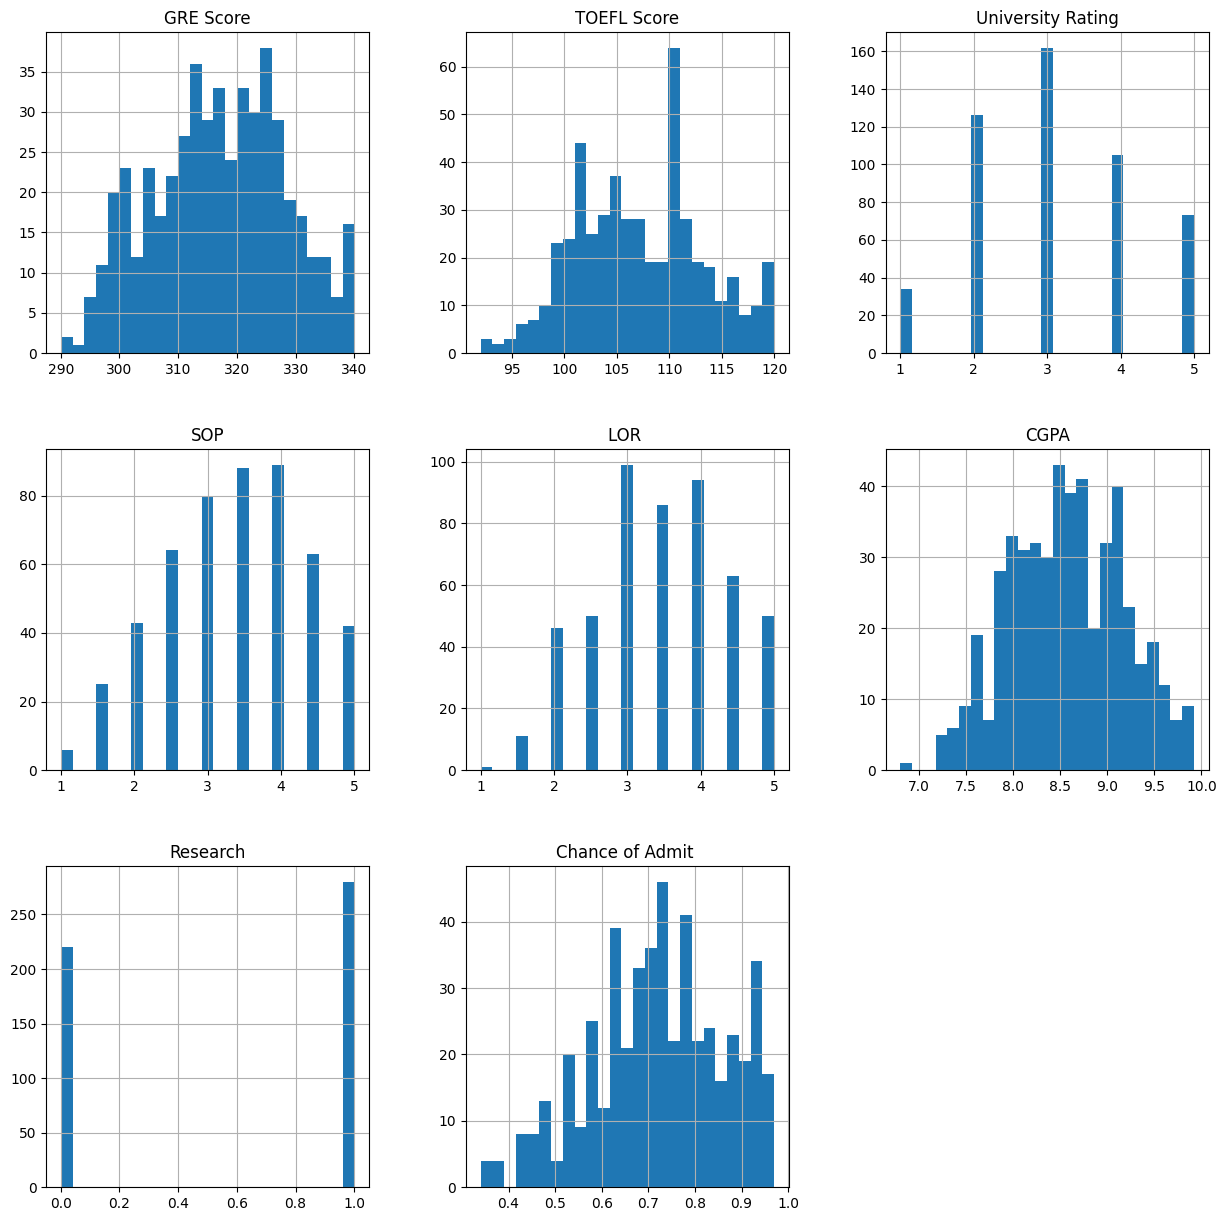

In [4]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [5]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [6]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
!pip install livelossplot

In [8]:
# Celda 1
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras import backend as K
from keras.callbacks import EarlyStopping, ModelCheckpoint
from livelossplot import PlotLossesKeras

In [9]:
# Escalar los datos
scaler = StandardScaler()
scaler.fit(X)

X_train_sc = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test_sc = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

X_train_sc = np.array(X_train_sc)
X_test_sc = np.array(X_test_sc)

y_train_arr = np.array(yTrain)
y_test_arr  = np.array(yTest)

In [13]:
# Definición de dimensiones de entrada y salida
dims = X_train_sc.shape[1]
output_var = 1

print(dims, 'input variables')
print(output_var, 'output variables')

7 input variables
1 output variables


In [24]:
K.clear_session()

# Definición de la red neuronal
model = Sequential()
model.add(Dense(output_var, input_shape=(dims,)))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
# Definicion del optimizador y la función de pérdida
model.compile(optimizer='sgd', loss='mean_squared_error')

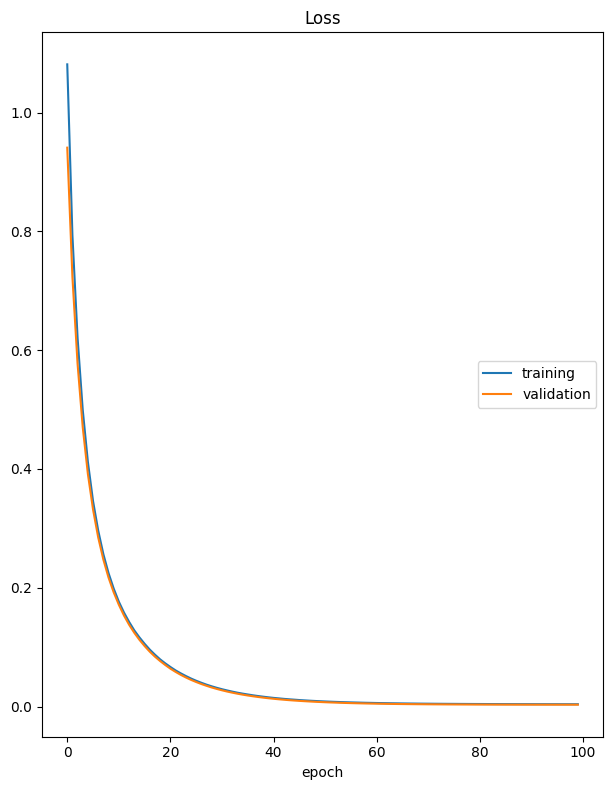

Loss
	training         	 (min:    0.004, max:    1.081, cur:    0.004)
	validation       	 (min:    0.003, max:    0.941, cur:    0.003)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0039 - val_loss: 0.0031


In [26]:
# Entrenamiento de la red neuronal con 100 épocas
model.fit(X_train_sc, y_train_arr,
          verbose=1,
          epochs=100,
          validation_data=(X_test_sc, y_test_arr),
          callbacks=[PlotLossesKeras()])

Para la **función de pérdida** se seleccionó el error cuadrático medio, MSE, como función de pérdida porque el problema corresponde a una regresión, donde la variable objetivo es una probabilidad continua de admisión. Esta función penaliza con mayor fuerza los errores grandes y es ampliamente usada en redes neuronales para problemas de predicción numérica.

La selección del **optimizador** y el número de **épocas** se realizó a partir de experimentación de distintas alternativas con el fin de obtener el mejor rendimiento posible. En lo que respecta al optimizador, se realizaron inicialmente pruebas con 'adam' pero con 'sgd' se encontró una convergencia más rápida y un mse menor. Por otro lado, con el número de épocas se probaron varios valores y se decidió mantener el valor en 100, ya que con esa cantidad todas las alternativas probadas se estabilizaban completamente.

In [27]:
# Predicciones y desempeño del modelo
y_pred = model.predict(X_test_sc).flatten()

mae = mean_absolute_error(y_test_arr, y_pred)
mse = mean_squared_error(y_test_arr,  y_pred)

print(f"\nDesempeño en set de prueba:")
print(f"  MAE : {mae:.4f}")
print(f"  MSE : {mse:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Desempeño en set de prueba:
  MAE : 0.0414
  MSE : 0.0031


## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
# Celda 2


## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
# Celda 3


## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 4
